In [10]:
# Notebook 05 : Feature Engineering
!pip -q install \
numpy \
pandas \
scipy \
scikit-learn \
astropy \
pyarrow \
plotly \
tqdm

In [2]:
import gc
import json
import logging
import warnings

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px

from scipy.stats import (
    skew,
    kurtosis,
    median_abs_deviation
)

from scipy.signal import find_peaks

from scipy.fft import fft, fftfreq

from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [11]:

PROJECT_NAME = "Exoplanet-detection"

ROOT_DIR = Path("D:/MachineLearning") / PROJECT_NAME

LIGHTCURVE_DIR = ROOT_DIR / "data" / "processed" / "lightcurves"

CANDIDATE_DIR = ROOT_DIR / "data" / "processed" / "candidates"

FEATURE_DIR = ROOT_DIR / "data" / "processed" / "features"

REPORT_DIR = ROOT_DIR / "reports"

LOG_DIR = ROOT_DIR / "logs"

FIGURE_DIR = ROOT_DIR / "figures" / "feature_analysis"

FEATURE_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration Loaded.")

Configuration Loaded.


In [14]:
LOG_FILE = LOG_DIR / "notebook_05.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler(LOG_FILE),
        logging.StreamHandler()
    ],
    force=True
)

logger = logging.getLogger("Notebook05")

logger.info("Notebook 05 Started")
print(LOG_FILE)

2026-07-27 18:16:10,008 | INFO | Notebook 05 Started


D:\MachineLearning\Exoplanet-detection\logs\notebook_05.log


In [18]:
candidate_csv = CANDIDATE_DIR / "candidate_catalog.csv"

candidate_df = pd.read_csv(candidate_csv)

print(f"Candidates Loaded : {len(candidate_df):,}")

display(candidate_df.head())

Candidates Loaded : 89


,tic_id,sector,source_file,period,duration,depth,epoch,sde,transit_snr,bls_power,distinct_transit_count,detector,confidence_score,quality_flag,rms,photometric_snr,num_points,estimated_transit_depth
0,100990000,3,TIC_100990000_Sector_3.parquet,9.581046,0.088920,0.999720,1386.184858,9.485989,8.836415,NaN,2,TLS,0.408613,REVIEW,0.000316,3167.188593,13532,0.001210
1,120252452,40,TIC_120252452_Sector_40.parquet,7.136761,0.039792,0.995005,2392.173341,6.523080,5.057516,NaN,4,TLS,0.316497,REJECT,0.008784,113.838699,19611,0.034610
2,120422519,53,TIC_120422519_Sector_53.parquet,6.957944,0.060194,0.993955,2746.613965,4.383445,4.529865,NaN,4,TLS,0.257778,REJECT,0.014823,67.462511,16991,0.062193
3,120691237,80,TIC_120691237_Sector_80.parquet,4.807281,0.032424,0.991279,3482.272404,4.895779,4.635307,NaN,6,TLS,0.291490,REJECT,0.018543,53.927798,17255,0.083770
4,121395761,40,TIC_121395761_Sector_40.parquet,7.075744,0.093817,0.992625,2390.960286,4.909971,4.760164,NaN,3,TLS,0.253902,REJECT,0.019285,51.853578,19609,0.079758


In [36]:
candidate_csv = CANDIDATE_DIR / "candidate_catalog.csv"

candidate_df = pd.read_csv(candidate_csv)

print(f"Candidates Loaded : {len(candidate_df):,}")

display(candidate_df.head(10))

Candidates Loaded : 89


,tic_id,sector,source_file,period,duration,depth,epoch,sde,transit_snr,bls_power,distinct_transit_count,detector,confidence_score,quality_flag,rms,photometric_snr,num_points,estimated_transit_depth
0,100990000,3,TIC_100990000_Sector_3.parquet,9.581046,0.088920,0.999720,1386.184858,9.485989,8.836415,NaN,2,TLS,0.408613,REVIEW,0.000316,3167.188593,13532,0.001210
1,120252452,40,TIC_120252452_Sector_40.parquet,7.136761,0.039792,0.995005,2392.173341,6.523080,5.057516,NaN,4,TLS,0.316497,REJECT,0.008784,113.838699,19611,0.034610
2,120422519,53,TIC_120422519_Sector_53.parquet,6.957944,0.060194,0.993955,2746.613965,4.383445,4.529865,NaN,4,TLS,0.257778,REJECT,0.014823,67.462511,16991,0.062193
3,120691237,80,TIC_120691237_Sector_80.parquet,4.807281,0.032424,0.991279,3482.272404,4.895779,4.635307,NaN,6,TLS,0.291490,REJECT,0.018543,53.927798,17255,0.083770
4,121395761,40,TIC_121395761_Sector_40.parquet,7.075744,0.093817,0.992625,2390.960286,4.909971,4.760164,NaN,3,TLS,0.253902,REJECT,0.019285,51.853578,19609,0.079758
5,121467823,75,TIC_121467823_Sector_75.parquet,1.895515,0.027660,0.997795,3340.722143,6.316764,4.972502,NaN,15,TLS,0.330266,REJECT,0.006564,152.335241,19474,0.027426
6,121598758,80,TIC_121598758_Sector_80.parquet,7.444309,0.116330,0.989178,3485.963461,5.655482,4.645915,NaN,2,TLS,0.249393,REJECT,0.027997,35.718596,15884,0.123161
7,121603794,40,TIC_121603794_Sector_40.parquet,2.191044,0.009917,0.999621,2390.878286,4.090544,3.823339,NaN,13,TLS,0.259168,REJECT,0.006106,163.773926,115324,0.030106
8,121785939,80,TIC_121785939_Sector_80.parquet,0.998777,0.088465,0.990735,3480.419545,6.616275,6.331033,NaN,24,TLS,0.359897,REJECT,0.050434,19.828011,17117,0.205193
9,121988890,80,TIC_121988890_Sector_80.parquet,1.133430,0.024164,0.991313,3480.975494,6.806078,5.095390,NaN,20,TLS,0.343732,REJECT,0.030192,33.121395,17277,0.125997


In [37]:
required_columns = [

    "tic_id",

    "sector",

    "source_file",

    "period",

    "duration",

    "depth",

    "epoch",

    "sde",

    "transit_snr",

    "bls_power",

    "confidence_score"

]

missing = [

    c for c in required_columns

    if c not in candidate_df.columns

]

if missing:
    raise ValueError(
        f"Missing columns: {missing}"
    )

print("Candidate catalog validated.")

Candidate catalog validated.


In [39]:
processed_files = sorted(
    LIGHTCURVE_DIR.glob("*.parquet")
)

print(f"Processed Light Curves : {len(processed_files):,}")

if len(processed_files) == 0:
    raise FileNotFoundError(
        "No processed light curves found."
    )

Processed Light Curves : 89


In [40]:
lightcurve_lookup = {

    file.name: file

    for file in processed_files

}

print(
    f"Lookup Table Size : {len(lightcurve_lookup):,}"
)

Lookup Table Size : 89


In [41]:
sample_candidate = candidate_df.iloc[0]

sample_curve = pd.read_parquet(

    lightcurve_lookup[
        sample_candidate["source_file"]
    ]

)

display(sample_candidate)

sample_curve.head()

tic_id                                          100990000
sector                                                  3
source_file                TIC_100990000_Sector_3.parquet
period                                           9.581046
duration                                          0.08892
depth                                             0.99972
epoch                                         1386.184858
sde                                              9.485989
transit_snr                                      8.836415
bls_power                                             NaN
distinct_transit_count                                  2
detector                                              TLS
confidence_score                                 0.408613
quality_flag                                       REVIEW
rms                                              0.000316
photometric_snr                               3167.188593
num_points                                          13532
estimated_tran

,tic_id,sector,mission,author,target_name,cadence_sec,time,flux,flux_err,quality,trend
0,100990000,3,TESS,SPOC,100990000,21.661595,1385.950975,0.999648,40.051029,0,128491.154483
1,100990000,3,TESS,SPOC,100990000,21.661595,1385.952364,1.000761,40.076237,0,128491.278858
2,100990000,3,TESS,SPOC,100990000,21.661595,1385.953753,1.000269,40.061535,0,128491.029725
3,100990000,3,TESS,SPOC,100990000,21.661595,1385.955142,0.999865,40.054287,0,128490.664490
4,100990000,3,TESS,SPOC,100990000,21.661595,1385.956531,1.000046,40.054855,0,128490.364681


In [42]:

required = [

    "time",

    "flux",

    "flux_err"

]

missing = [

    c

    for c in required

    if c not in sample_curve.columns

]

if missing:

    raise ValueError(
        f"Missing columns: {missing}"
    )

print("Light curve verified.")

Light curve verified.


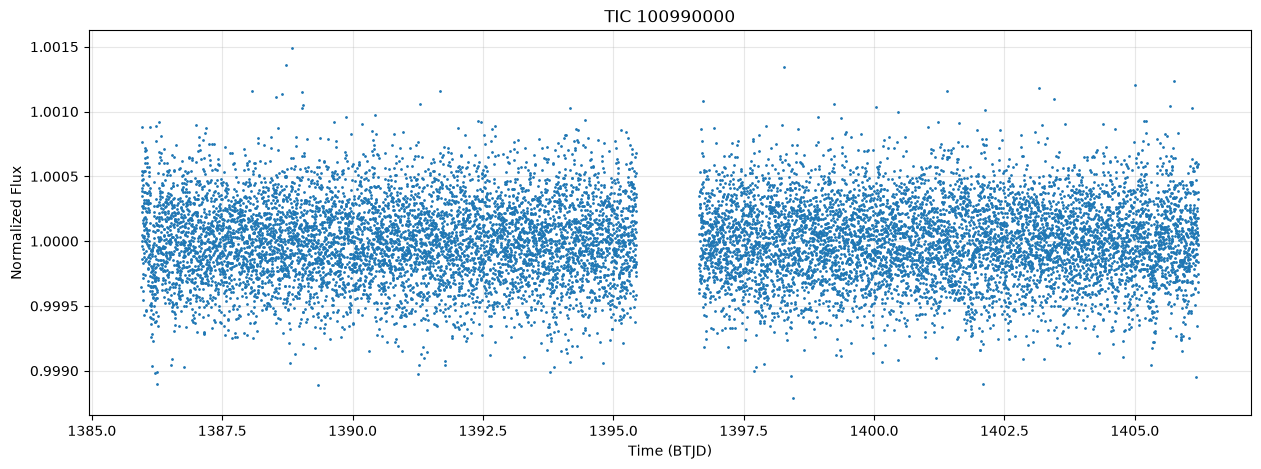

In [43]:
plt.figure(figsize=(15,5))

plt.plot(

    sample_curve["time"],

    sample_curve["flux"],

    ".",

    markersize=2

)

plt.xlabel("Time (BTJD)")

plt.ylabel("Normalized Flux")

plt.title(

    f"TIC {sample_candidate['tic_id']}"

)

plt.grid(alpha=0.3)

plt.show()

In [44]:
FEATURE_GROUPS = {

    "transit": [],

    "statistical": [],

    "temporal": [],

    "frequency": [],

    "quality": []

}

print("Feature groups initialized.")

FEATURE_GROUPS

Feature groups initialized.


{'transit': [],
 'statistical': [],
 'temporal': [],
 'frequency': [],
 'quality': []}

In [46]:
print("Notebook 05 - Part 1 Completed")

print(f"Candidates        : {len(candidate_df):,}")

print(f"Light Curves      : {len(processed_files):,}")

print(f"Feature Directory : {FEATURE_DIR}")

print(f"Figures Directory : {FIGURE_DIR}")

logger.info("Notebook 05 Part 1 Completed")

2026-07-27 20:37:49,689 | INFO | Notebook 05 Part 1 Completed


Notebook 05 - Part 1 Completed
Candidates        : 89
Light Curves      : 89
Feature Directory : D:\MachineLearning\Exoplanet-detection\data\processed\features
Figures Directory : D:\MachineLearning\Exoplanet-detection\figures\feature_analysis


In [47]:
#Runtime summary of the notebook
print("Notebook 05 - Part 1 Completed")

print(f"Candidates        : {len(candidate_df):,}")

print(f"Light Curves      : {len(processed_files):,}")

print(f"Feature Directory : {FEATURE_DIR}")

print(f"Figures Directory : {FIGURE_DIR}")

logger.info("Notebook 05 Part 1 Completed")

2026-07-27 20:38:26,598 | INFO | Notebook 05 Part 1 Completed


Notebook 05 - Part 1 Completed
Candidates        : 89
Light Curves      : 89
Feature Directory : D:\MachineLearning\Exoplanet-detection\data\processed\features
Figures Directory : D:\MachineLearning\Exoplanet-detection\figures\feature_analysis


### Part-2 of Feature Engineering 

In [49]:
# Statistical Feature Names

STATISTICAL_FEATURES = [

    "mean_flux",
    "median_flux",
    "std_flux",
    "variance",

    "minimum_flux",
    "maximum_flux",
    "dynamic_range",

    "rms",
    "mad",

    "skewness",
    "kurtosis",

    "percentile_5",
    "percentile_25",
    "percentile_75",
    "percentile_95",

    "iqr",

    "flux_entropy",

    "zero_crossings"

]

FEATURE_GROUPS["statistical"] = STATISTICAL_FEATURES

print(f"{len(STATISTICAL_FEATURES)} statistical features registered.")

18 statistical features registered.


In [50]:
# All the utility functions for feature engineering are here 
def compute_rms(values):

    values = np.asarray(values)

    return np.sqrt(np.mean(values ** 2))


def compute_entropy(values, bins=50):

    hist, _ = np.histogram(values, bins=bins)

    hist = hist.astype(float)

    hist /= hist.sum()

    hist = hist[hist > 0]

    return -(hist * np.log2(hist)).sum()


def compute_zero_crossings(values):

    values = values - np.median(values)

    return np.where(np.diff(np.sign(values)))[0].size

In [51]:
# Statistical Feature Extractor

def extract_statistical_features(lightcurve):

    flux = lightcurve["flux"].to_numpy()

    features = {}

    features["mean_flux"] = np.mean(flux)

    features["median_flux"] = np.median(flux)

    features["std_flux"] = np.std(flux)

    features["variance"] = np.var(flux)

    features["minimum_flux"] = np.min(flux)

    features["maximum_flux"] = np.max(flux)

    features["dynamic_range"] = (

        np.max(flux) -

        np.min(flux)

    )

    features["rms"] = compute_rms(flux)

    features["mad"] = median_abs_deviation(flux)

    features["skewness"] = skew(flux)

    features["kurtosis"] = kurtosis(flux)

    features["percentile_5"] = np.percentile(flux,5)

    features["percentile_25"] = np.percentile(flux,25)

    features["percentile_75"] = np.percentile(flux,75)

    features["percentile_95"] = np.percentile(flux,95)

    features["iqr"] = (

        features["percentile_75"] -

        features["percentile_25"]

    )

    features["flux_entropy"] = compute_entropy(flux)

    features["zero_crossings"] = compute_zero_crossings(flux)

    return features

In [52]:
# Test Statistical Extractor

stat_features = extract_statistical_features(sample_curve)

print(f"Extracted {len(stat_features)} features")

pd.DataFrame(

    stat_features.items(),

    columns=["Feature","Value"]

)

Extracted 18 features


,Feature,Value
0,mean_flux,1.000003e+00
1,median_flux,1.000000e+00
2,std_flux,3.157374e-04
3,variance,9.969013e-08
4,minimum_flux,9.987899e-01
5,maximum_flux,1.001490e+00
6,dynamic_range,2.700428e-03
7,rms,1.000003e+00
8,mad,2.104488e-04
9,skewness,6.934031e-02


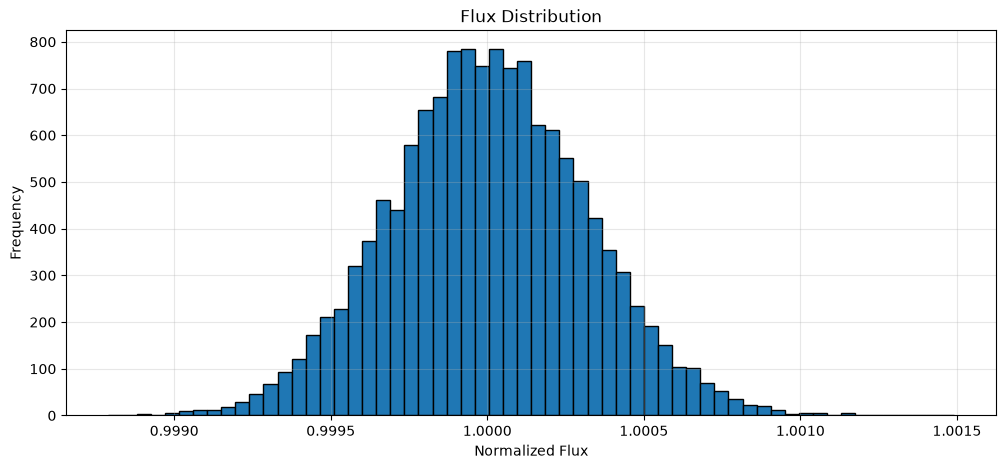

In [53]:
# Statistical Distribution

plt.figure(figsize=(12,5))

plt.hist(

    sample_curve["flux"],

    bins=60,

    edgecolor="black"

)

plt.xlabel("Normalized Flux")

plt.ylabel("Frequency")

plt.title("Flux Distribution")

plt.grid(alpha=0.3)

plt.show()

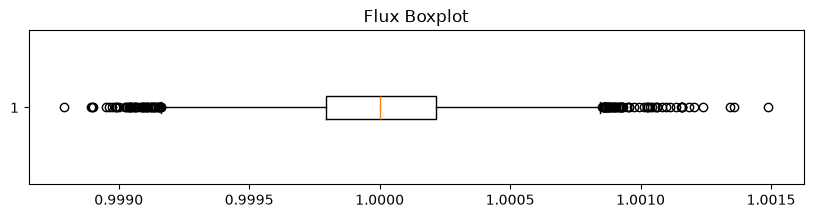

In [54]:
# Flux Boxplot

plt.figure(figsize=(10,2))

plt.boxplot(

    sample_curve["flux"],

    vert=False

)

plt.title("Flux Boxplot")

plt.show()

In [55]:
# Validate Statistical Features

missing = [

    feature

    for feature in FEATURE_GROUPS["statistical"]

    if feature not in stat_features

]

if len(missing):

    raise ValueError(

        f"Missing Features: {missing}"

    )

print("All statistical features extracted successfully.")

All statistical features extracted successfully.


In [56]:
# Pipeline Test for first 10 candidates

feature_rows = []

for _, row in candidate_df.head(10).iterrows():

    lc_path = lightcurve_lookup[row["source_file"]]

    lc = pd.read_parquet(lc_path)

    stats = extract_statistical_features(lc)

    stats["tic_id"] = row["tic_id"]

    feature_rows.append(stats)

test_df = pd.DataFrame(feature_rows)

print(test_df.shape)

display(test_df.head())

(10, 19)


,mean_flux,median_flux,std_flux,variance,minimum_flux,maximum_flux,dynamic_range,rms,mad,skewness,kurtosis,percentile_5,percentile_25,percentile_75,percentile_95,iqr,flux_entropy,zero_crossings,tic_id
0,1.000003,1.0,0.000316,9.969013e-08,0.998790,1.001490,0.002700,1.000003,0.000210,0.069340,0.132021,0.999485,0.999793,1.000214,1.000525,0.000421,4.592016,6583,100990000
1,1.000077,1.0,0.008784,7.716496e-05,0.965390,1.035600,0.070210,1.000115,0.005844,0.010462,0.111957,0.985641,0.994244,1.005930,1.014609,0.011686,4.692568,9715,120252452
2,0.999908,1.0,0.014823,2.197227e-04,0.937807,1.056137,0.118330,1.000018,0.009901,-0.012335,0.062769,0.975531,0.989964,1.009807,1.024079,0.019843,4.692344,8504,120422519
3,0.999880,1.0,0.018543,3.438544e-04,0.916230,1.075800,0.159570,1.000052,0.012093,-0.019136,0.361775,0.969519,0.987879,1.012059,1.030083,0.024180,4.583144,8594,120691237
4,0.999922,1.0,0.019285,3.719140e-04,0.920242,1.085775,0.165533,1.000108,0.012894,-0.009120,0.115879,0.968457,0.986986,1.012783,1.031715,0.025797,4.588340,9817,121395761


In [57]:
# Transit Feature Registry

TRANSIT_FEATURES = [

    # Detection
    "period",
    "duration",
    "depth",
    "epoch",

    # Detection Quality
    "sde",
    "transit_snr",
    "bls_power",
    "distinct_transit_count",

    # Confidence
    "confidence_score",

    # Derived Features
    "depth_ppm",
    "depth_percent",
    "duration_hours",
    "transits_per_day",
    "depth_duration_ratio",
    "snr_per_transit",
    "period_frequency",
    "duty_cycle"

]

FEATURE_GROUPS["transit"] = TRANSIT_FEATURES

print(f"{len(TRANSIT_FEATURES)} transit features registered.")

17 transit features registered.


In [58]:
# Transit Feature Extractor

def extract_transit_features(candidate):

    features = {}

    # Original features
    features["period"] = candidate["period"]

    features["duration"] = candidate["duration"]

    features["depth"] = candidate["depth"]

    features["epoch"] = candidate["epoch"]

    features["sde"] = candidate["sde"]

    features["transit_snr"] = candidate["transit_snr"]

    features["bls_power"] = candidate["bls_power"]

    features["distinct_transit_count"] = candidate[
        "distinct_transit_count"
    ]

    features["confidence_score"] = candidate[
        "confidence_score"
    ]

    return features

In [59]:
# Derived Transit Features

def compute_transit_derived_features(features):

    period = features["period"]

    duration = features["duration"]

    depth = features["depth"]

    snr = features["transit_snr"]

    n_transits = max(
        features["distinct_transit_count"],
        1
    )

    # -----------------------------
    # Unit conversions
    # -----------------------------

    features["depth_ppm"] = depth * 1e6

    features["depth_percent"] = depth * 100

    features["duration_hours"] = duration * 24

    # -----------------------------
    # Ratios
    # -----------------------------

    features["transits_per_day"] = 1 / period

    features["depth_duration_ratio"] = depth / duration

    features["snr_per_transit"] = snr / n_transits

    features["period_frequency"] = 1 / period

    features["duty_cycle"] = duration / period

    return features

In [60]:
# Complete Transit Extractor

def get_transit_features(candidate):

    features = extract_transit_features(candidate)

    features = compute_transit_derived_features(features)

    return features

In [61]:
# Test Transit Features

sample_candidate = candidate_df.iloc[0]

transit_features = get_transit_features(sample_candidate)

print(f"Extracted {len(transit_features)} transit features")

display(

    pd.DataFrame(

        transit_features.items(),

        columns=["Feature","Value"]

    )

)

Extracted 17 transit features


,Feature,Value
0,period,9.581046
1,duration,0.088920
2,depth,0.999720
3,epoch,1386.184858
4,sde,9.485989
5,transit_snr,8.836415
6,bls_power,NaN
7,distinct_transit_count,2.000000
8,confidence_score,0.408613
9,depth_ppm,999719.959175


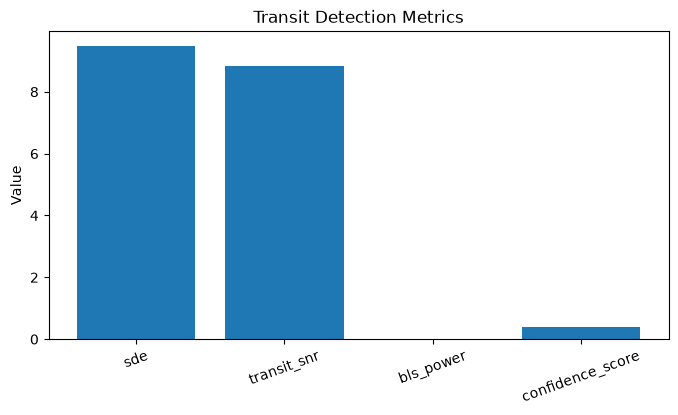

In [62]:
# Transit Diagnostics

fig, ax = plt.subplots(figsize=(8,4))

metrics = [

    "sde",

    "transit_snr",

    "bls_power",

    "confidence_score"

]

values = [

    transit_features[m]

    for m in metrics

]

ax.bar(metrics, values)

ax.set_ylabel("Value")

ax.set_title("Transit Detection Metrics")

plt.xticks(rotation=20)

plt.show()

In [63]:
# Transit Feature Pipeline Test

rows = []

for _, candidate in candidate_df.head(10).iterrows():

    features = get_transit_features(candidate)

    features["tic_id"] = candidate["tic_id"]

    rows.append(features)

transit_df = pd.DataFrame(rows)

print(transit_df.shape)

display(transit_df.head())

(10, 18)


,period,duration,depth,epoch,sde,transit_snr,bls_power,distinct_transit_count,confidence_score,depth_ppm,depth_percent,duration_hours,transits_per_day,depth_duration_ratio,snr_per_transit,period_frequency,duty_cycle,tic_id
0,9.581046,0.088920,0.999720,1386.184858,9.485989,8.836415,NaN,2,0.408613,999719.959175,99.971996,2.134068,0.104373,11.242976,4.418207,0.104373,0.009281,100990000
1,7.136761,0.039792,0.995005,2392.173341,6.523080,5.057516,NaN,4,0.316497,995005.207591,99.500521,0.955000,0.140120,25.005366,1.264379,0.140120,0.005576,120252452
2,6.957944,0.060194,0.993955,2746.613965,4.383445,4.529865,NaN,4,0.257778,993955.336507,99.395534,1.444652,0.143721,16.512576,1.132466,0.143721,0.008651,120422519
3,4.807281,0.032424,0.991279,3482.272404,4.895779,4.635307,NaN,6,0.291490,991278.695066,99.127870,0.778182,0.208018,30.572138,0.772551,0.208018,0.006745,120691237
4,7.075744,0.093817,0.992625,2390.960286,4.909971,4.760164,NaN,3,0.253902,992624.726986,99.262473,2.251614,0.141328,10.580405,1.586721,0.141328,0.013259,121395761


In [64]:
# Validation

missing = [

    feature

    for feature in FEATURE_GROUPS["transit"]

    if feature not in transit_features

]

if missing:

    raise ValueError(

        f"Missing transit features: {missing}"

    )

print("Transit feature extraction successful.")

Transit feature extraction successful.


In [65]:
# Temporal Feature Registry

TEMPORAL_FEATURES = [

    "observation_duration_days",
    "num_observations",
    "median_cadence_days",
    "mean_cadence_days",
    "std_cadence_days",

    "cadence_minutes",

    "largest_gap_days",
    "mean_gap_days",
    "gap_fraction",

    "sampling_density",

    "duty_cycle_observation",

    "time_span_hours"

]

FEATURE_GROUPS["temporal"] = TEMPORAL_FEATURES

print(f"{len(TEMPORAL_FEATURES)} temporal features registered.")

12 temporal features registered.


In [66]:
# Temporal Feature Extractor

def extract_temporal_features(lightcurve):

    time = lightcurve["time"].to_numpy()

    features = {}

    if len(time) < 2:

        for feature in TEMPORAL_FEATURES:
            features[feature] = np.nan

        return features

    cadence = np.diff(time)

    duration = time.max() - time.min()

    features["observation_duration_days"] = duration

    features["num_observations"] = len(time)

    features["median_cadence_days"] = np.median(cadence)

    features["mean_cadence_days"] = np.mean(cadence)

    features["std_cadence_days"] = np.std(cadence)

    features["cadence_minutes"] = (
        features["median_cadence_days"] * 24 * 60
    )

    features["largest_gap_days"] = np.max(cadence)

    features["mean_gap_days"] = np.mean(cadence)

    features["gap_fraction"] = (

        np.max(cadence)

        /

        duration

    )

    features["sampling_density"] = (

        len(time)

        /

        duration

    )

    features["duty_cycle_observation"] = (

        np.sum(cadence)

        /

        duration

    )

    features["time_span_hours"] = duration * 24

    return features

In [67]:
# Test Temporal Features

temporal_features = extract_temporal_features(sample_curve)

print(f"Extracted {len(temporal_features)} temporal features")

display(

    pd.DataFrame(

        temporal_features.items(),

        columns=["Feature","Value"]

    )

)

Extracted 12 temporal features


,Feature,Value
0,observation_duration_days,20.265641
1,num_observations,13532.000000
2,median_cadence_days,0.001389
3,mean_cadence_days,0.001498
4,std_cadence_days,0.010308
5,cadence_minutes,2.000036
6,largest_gap_days,1.200023
7,mean_gap_days,0.001498
8,gap_fraction,0.059215
9,sampling_density,667.731160


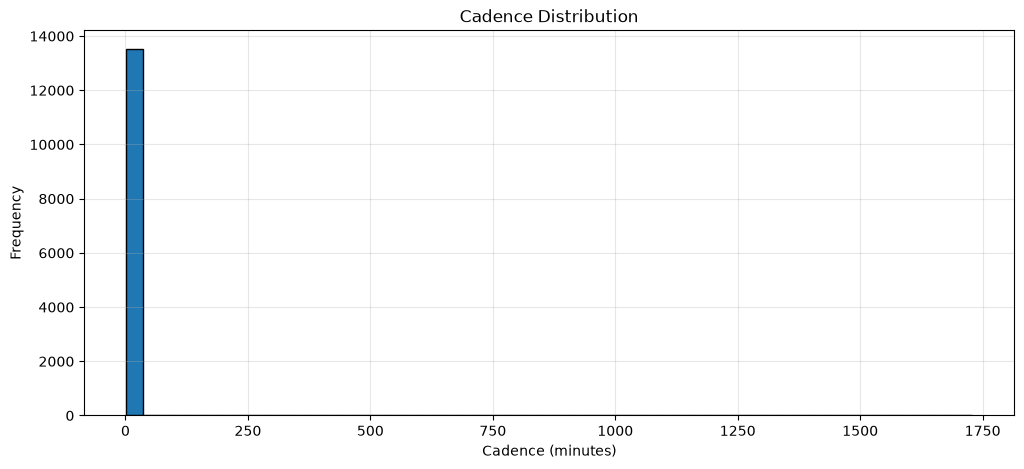

In [68]:
# Cadence Distribution

cadence = np.diff(sample_curve["time"])

plt.figure(figsize=(12,5))

plt.hist(

    cadence * 24 * 60,

    bins=50,

    edgecolor="black"

)

plt.xlabel("Cadence (minutes)")

plt.ylabel("Frequency")

plt.title("Cadence Distribution")

plt.grid(alpha=0.3)

plt.show()

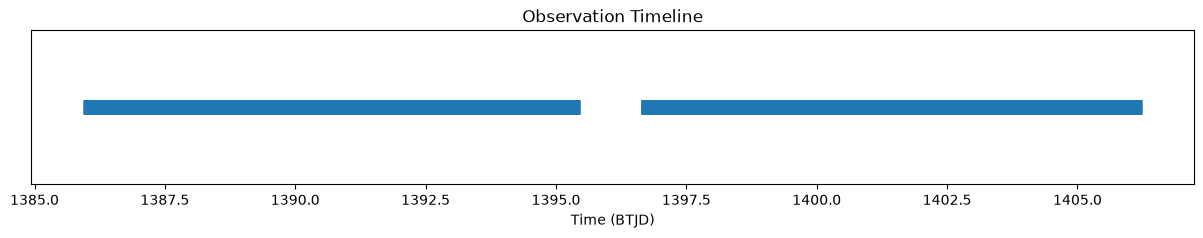

In [69]:
# Observation Timeline

plt.figure(figsize=(15,2))

plt.plot(

    sample_curve["time"],

    np.ones(len(sample_curve)),

    "|",

    markersize=10

)

plt.yticks([])

plt.xlabel("Time (BTJD)")

plt.title("Observation Timeline")

plt.show()

In [70]:
# Largest Observation Gaps

cadence = np.diff(sample_curve["time"])

largest = np.sort(cadence)[::-1][:10]

gap_df = pd.DataFrame({

    "Gap (days)": largest,

    "Gap (hours)": largest * 24

})

display(gap_df)

,Gap (days),Gap (hours)
0,1.200023,28.800554
1,0.011111,0.266673
2,0.011111,0.266672
3,0.011111,0.266672
4,0.011111,0.266671
5,0.011111,0.266671
6,0.011111,0.266671
7,0.011111,0.266670
8,0.011111,0.266669
9,0.005556,0.133336


In [71]:
# Temporal Pipeline Test

rows = []

for _, candidate in candidate_df.head(10).iterrows():

    lc = pd.read_parquet(

        lightcurve_lookup[
            candidate["source_file"]
        ]

    )

    features = extract_temporal_features(lc)

    features["tic_id"] = candidate["tic_id"]

    rows.append(features)

temporal_df = pd.DataFrame(rows)

print(temporal_df.shape)

display(temporal_df.head())

(10, 13)


,observation_duration_days,num_observations,median_cadence_days,mean_cadence_days,std_cadence_days,cadence_minutes,largest_gap_days,mean_gap_days,gap_fraction,sampling_density,duty_cycle_observation,time_span_hours,tic_id
0,20.265641,13532,0.001389,0.001498,0.010308,2.000036,1.200023,0.001498,0.059215,667.731160,1.0,486.375385,100990000
1,28.200152,19611,0.001389,0.001438,0.006646,2.000016,0.931948,0.001438,0.033048,695.421785,1.0,676.803647,120252452
2,24.982340,16991,0.001389,0.001470,0.007784,2.000025,0.919461,0.001470,0.036804,680.120442,1.0,599.576155,120422519
3,26.447559,17255,0.001389,0.001533,0.012079,2.000024,1.516692,0.001533,0.057347,652.423161,1.0,634.741414,120691237
4,28.200260,19609,0.001389,0.001438,0.006646,2.000025,0.931952,0.001438,0.033048,695.348200,1.0,676.806239,121395761


In [72]:
# Validation

missing = [

    feature

    for feature in TEMPORAL_FEATURES

    if feature not in temporal_features

]

if missing:

    raise ValueError(

        f"Missing temporal features: {missing}"

    )

print("Temporal feature extraction successful.")

Temporal feature extraction successful.


In [73]:
# Frequency Feature Registry

FREQUENCY_FEATURES = [

    "dominant_frequency",

    "dominant_period",

    "dominant_power",

    "second_frequency",

    "second_power",

    "third_frequency",

    "third_power",

    "mean_spectral_power",

    "max_spectral_power",

    "spectral_std",

    "spectral_entropy",

    "spectral_energy",

    "harmonic_ratio",

    "power_concentration",

    "frequency_variance"

]

FEATURE_GROUPS["frequency"] = FREQUENCY_FEATURES

print(f"{len(FREQUENCY_FEATURES)} frequency features registered.")

15 frequency features registered.


In [ ]:
# FFT Computation

def compute_fft(lightcurve):

    time = lightcurve["time"].to_numpy()

    flux = lightcurve["flux"].to_numpy()

    flux = flux - np.mean(flux)

    dt = np.median(np.diff(time))

    fft_values = np.fft.rfft(flux)

    frequencies = np.fft.rfftfreq(
        len(flux),
        d=dt
    )

    power = np.abs(fft_values)**2

    return frequencies, power

In [ ]:
# Frequency Feature Extractor

def extract_frequency_features(lightcurve):

    freq, power = compute_fft(lightcurve)

    valid = freq > 0

    freq = freq[valid]
    power = power[valid]

    idx = np.argsort(power)[::-1]

    freq = freq[idx]
    power = power[idx]

    features = {}

    features["dominant_frequency"] = freq[0]

    features["dominant_period"] = 1 / freq[0]

    features["dominant_power"] = power[0]

    features["second_frequency"] = freq[1]

    features["second_power"] = power[1]

    features["third_frequency"] = freq[2]

    features["third_power"] = power[2]

    features["mean_spectral_power"] = np.mean(power)

    features["max_spectral_power"] = np.max(power)

    features["spectral_std"] = np.std(power)

    power_norm = power / power.sum()

    features["spectral_entropy"] = -np.sum(

        power_norm * np.log2(power_norm + 1e-12)

    )

    features["spectral_energy"] = np.sum(power)

    features["harmonic_ratio"] = (

        power[1] / power[0]

    )

    features["power_concentration"] = (

        power[:10].sum()

        /

        power.sum()

    )

    features["frequency_variance"] = np.var(freq)

    return features

In [ ]:
# Test Frequency Features

frequency_features = extract_frequency_features(sample_curve)

print(

    f"Extracted {len(frequency_features)} frequency features"

)

display(

    pd.DataFrame(

        frequency_features.items(),

        columns=["Feature","Value"]

    )

)

Extracted 15 frequency features


,Feature,Value
0,dominant_frequency,2.021837
1,dominant_period,0.494600
2,dominant_power,0.022058
3,second_frequency,309.341103
4,second_power,0.014702
5,third_frequency,1.862219
6,third_power,0.012587
7,mean_spectral_power,0.001349
8,max_spectral_power,0.022058
9,spectral_std,0.001402


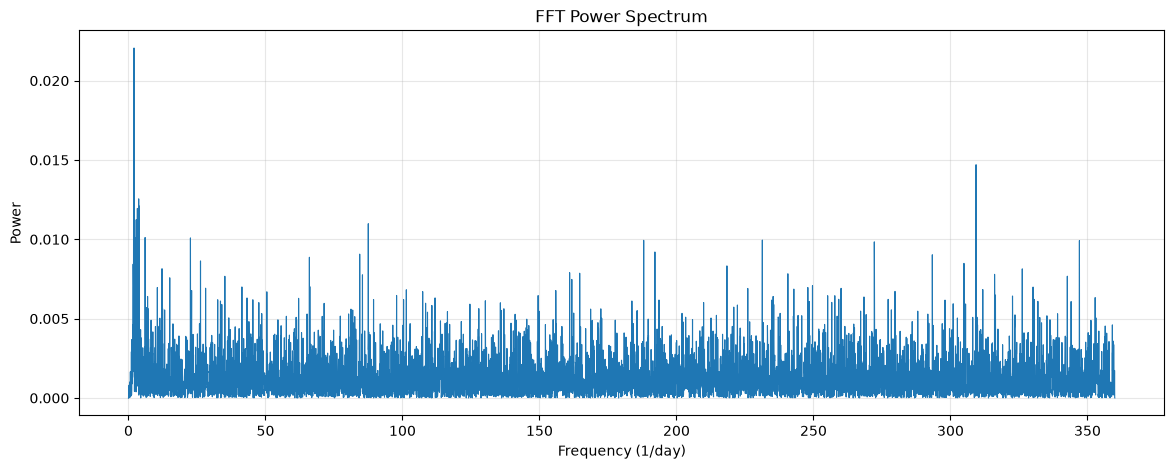

In [ ]:
# FFT Power Spectrum

freq, power = compute_fft(sample_curve)

plt.figure(figsize=(14,5))

plt.plot(

    freq,

    power,

    linewidth=0.8

)

plt.xlabel("Frequency (1/day)")

plt.ylabel("Power")

plt.title("FFT Power Spectrum")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Dominant Spectral Peaks

freq, power = compute_fft(sample_curve)

peaks, _ = find_peaks(

    power,

    prominence=np.std(power)

)

peak_df = pd.DataFrame({

    "Frequency": freq[peaks],

    "Power": power[peaks]

})

peak_df = peak_df.sort_values(

    "Power",

    ascending=False

)

display(

    peak_df.head(10)

)

,Frequency,Power
5,2.021837,0.022058
1062,309.341103,0.014702
4,1.862219,0.012587
13,3.724437,0.012550
15,3.937262,0.012098
12,3.245581,0.011947
10,2.819931,0.011232
317,87.524272,0.010985
6,2.128250,0.010290
21,6.065512,0.010114


In [ ]:
# Frequency Pipeline Test

rows = []

for _, candidate in candidate_df.head(10).iterrows():

    lc = pd.read_parquet(

        lightcurve_lookup[
            candidate["source_file"]
        ]

    )

    features = extract_frequency_features(lc)

    features["tic_id"] = candidate["tic_id"]

    rows.append(features)

frequency_df = pd.DataFrame(rows)

print(frequency_df.shape)

display(frequency_df.head())

(10, 16)


,dominant_frequency,dominant_period,dominant_power,second_frequency,second_power,third_frequency,third_power,mean_spectral_power,max_spectral_power,spectral_std,spectral_entropy,spectral_energy,harmonic_ratio,power_concentration,frequency_variance,tic_id
0,2.021837,0.494600,0.022058,309.341103,0.014702,1.862219,0.012587,0.001349,0.022058,0.001402,12.099128,9.127381,0.666532,0.014085,10799.606612,100990000
1,238.382650,0.004195,13.840627,272.636618,12.318017,1.945831,11.500818,1.513359,13.840627,1.510543,12.648441,14838.487631,0.889990,0.007541,10798.723660,120252452
2,235.349947,0.004249,48.039162,216.535511,40.025693,165.304311,33.376897,3.733529,48.039162,3.749012,12.441047,31716.326327,0.833189,0.009830,10798.463695,120422519
3,50.197033,0.019921,47.896239,240.011086,47.776040,241.388062,46.118257,5.933552,47.896239,5.873025,12.471290,51188.754663,0.997490,0.008510,10798.494023,120691237
4,255.809961,0.003909,65.512185,2.460064,65.046597,2.533499,60.026117,7.293234,65.512185,7.371655,12.642544,71502.863046,0.992893,0.008116,10798.629400,121395761


In [ ]:
# Validation

missing = [

    feature

    for feature in FREQUENCY_FEATURES

    if feature not in frequency_features

]

if missing:

    raise ValueError(

        f"Missing frequency features: {missing}"

    )

print("Frequency feature extraction successful.")

Frequency feature extraction successful.


In [81]:
# ============================================================
# Merge Feature Dictionaries
# ============================================================

def extract_all_features(candidate_row):

    lc = pd.read_parquet(

        lightcurve_lookup[
            candidate_row["source_file"]
        ]
    )

    features = {}

    # -----------------------------
    # Candidate Information
    # -----------------------------

    features["tic_id"] = candidate_row["tic_id"]

    features["sector"] = candidate_row["sector"]

    # -----------------------------
    # Statistical
    # -----------------------------

    features.update(

        extract_statistical_features(lc)

    )

    # -----------------------------
    # Transit
    # -----------------------------

    features.update(

        get_transit_features(candidate_row)

    )

    # -----------------------------
    # Temporal
    # -----------------------------

    features.update(

        extract_temporal_features(lc)

    )

    # -----------------------------
    # Frequency
    # -----------------------------

    features.update(

        extract_frequency_features(lc)

    )

    return features


In [82]:
# ============================================================
# Build Feature Dataset
# ============================================================

feature_rows = []

for _, candidate in tqdm(

    candidate_df.iterrows(),

    total=len(candidate_df)

):

    try:

        feature_rows.append(

            extract_all_features(candidate)

        )

    except Exception as e:

        logger.error(

            f"{candidate['tic_id']} : {e}"

        )

feature_df = pd.DataFrame(feature_rows)

print(feature_df.shape)

display(feature_df.head())

  0%|          | 0/89 [00:00<?, ?it/s]

(89, 64)


,tic_id,sector,mean_flux,median_flux,std_flux,variance,minimum_flux,maximum_flux,dynamic_range,rms,...,third_frequency,third_power,mean_spectral_power,max_spectral_power,spectral_std,spectral_entropy,spectral_energy,harmonic_ratio,power_concentration,frequency_variance
0,100990000,3,1.000003,1.0,0.000316,9.969013e-08,0.998790,1.001490,0.002700,1.000003,...,1.862219,0.012587,0.001349,0.022058,0.001402,12.099128,9.127381,0.666532,0.014085,10799.606612
1,120252452,40,1.000077,1.0,0.008784,7.716496e-05,0.965390,1.035600,0.070210,1.000115,...,1.945831,11.500818,1.513359,13.840627,1.510543,12.648441,14838.487631,0.889990,0.007541,10798.723660
2,120422519,53,0.999908,1.0,0.014823,2.197227e-04,0.937807,1.056137,0.118330,1.000018,...,165.304311,33.376897,3.733529,48.039162,3.749012,12.441047,31716.326327,0.833189,0.009830,10798.463695
3,120691237,80,0.999880,1.0,0.018543,3.438544e-04,0.916230,1.075800,0.159570,1.000052,...,241.388062,46.118257,5.933552,47.896239,5.873025,12.471290,51188.754663,0.997490,0.008510,10798.494023
4,121395761,40,0.999922,1.0,0.019285,3.719140e-04,0.920242,1.085775,0.165533,1.000108,...,2.533499,60.026117,7.293234,65.512185,7.371655,12.642544,71502.863046,0.992893,0.008116,10798.629400


In [ ]:
# Missing Values

missing = feature_df.isna().sum()

missing = missing[missing > 0]

missing.sort_values(
    ascending=False
)

bls_power    89
dtype: int64

In [84]:
# Handle Missing Values

numeric_columns = feature_df.select_dtypes(

    include=np.number

).columns

feature_df[numeric_columns] = feature_df[
    numeric_columns
].fillna(

    feature_df[numeric_columns].median()

)

print("Missing values handled.")

Missing values handled.


In [85]:
# ============================================================
# Remove Constant Features
# ============================================================

constant_columns = [

    c

    for c in feature_df.columns

    if feature_df[c].nunique() <= 1

]

print(constant_columns)

feature_df.drop(

    columns=constant_columns,

    inplace=True

)

print(feature_df.shape)

['bls_power', 'duty_cycle_observation']
(89, 62)


In [86]:
# ============================================================
# Duplicate Columns
# ============================================================

duplicate_columns = feature_df.T.duplicated()

duplicate_columns = feature_df.columns[
    duplicate_columns
]

print(list(duplicate_columns))

['period_frequency', 'mean_gap_days', 'max_spectral_power']


In [87]:
# ============================================================
# Remove Duplicate Columns
# ============================================================

feature_df = feature_df.loc[
    :,
    ~feature_df.T.duplicated()
]

print(feature_df.shape)

(89, 59)


In [88]:
# ============================================================
# Correlation Matrix
# ============================================================

correlation = feature_df.select_dtypes(

    include=np.number

).corr().abs()

correlation.head()

,tic_id,sector,mean_flux,median_flux,std_flux,variance,minimum_flux,maximum_flux,dynamic_range,rms,...,second_power,third_frequency,third_power,mean_spectral_power,spectral_std,spectral_entropy,spectral_energy,harmonic_ratio,power_concentration,frequency_variance
tic_id,1.000000,0.055016,0.059240,0.047990,0.026378,0.024259,0.031893,0.034963,0.033549,0.038371,...,0.025747,0.067315,0.015788,0.025098,0.023119,0.241492,0.020241,0.006774,0.245397,0.057431
sector,0.055016,1.000000,0.005209,0.011059,0.488945,0.330639,0.495373,0.481262,0.490096,0.309775,...,0.263840,0.083742,0.291502,0.288106,0.289923,0.114844,0.235329,0.003064,0.251915,0.091959
mean_flux,0.059240,0.005209,1.000000,0.188497,0.135058,0.092085,0.137747,0.184857,0.161883,0.350250,...,0.146728,0.091376,0.133782,0.104875,0.107588,0.132671,0.108900,0.000873,0.211149,0.022340
median_flux,0.047990,0.011059,0.188497,1.000000,0.012653,0.107985,0.021451,0.016651,0.019121,0.052685,...,0.056891,0.009536,0.047824,0.113654,0.109889,0.003501,0.118311,0.047430,0.010479,0.007755
std_flux,0.026378,0.488945,0.135058,0.012653,1.000000,0.939325,0.992160,0.993136,0.996259,0.919277,...,0.877028,0.032426,0.901546,0.914323,0.915951,0.017438,0.870052,0.075006,0.235316,0.236024


In [89]:
# ============================================================
# Remove Correlated Features
# ============================================================

threshold = 0.95

upper = correlation.where(

    np.triu(

        np.ones(correlation.shape),

        k=1

    ).astype(bool)

)

drop_columns = [

    column

    for column in upper.columns

    if any(

        upper[column] > threshold

    )

]

print(drop_columns)

feature_df.drop(

    columns=drop_columns,

    inplace=True
)

['minimum_flux', 'maximum_flux', 'dynamic_range', 'rms', 'mad', 'percentile_5', 'percentile_25', 'percentile_75', 'percentile_95', 'iqr', 'epoch', 'confidence_score', 'depth_ppm', 'depth_percent', 'duration_hours', 'transits_per_day', 'num_observations', 'cadence_minutes', 'gap_fraction', 'sampling_density', 'time_span_hours', 'third_power', 'mean_spectral_power', 'spectral_std', 'spectral_energy', 'power_concentration', 'frequency_variance']


In [90]:
# ============================================================
# Dataset Summary
# ============================================================

summary = pd.DataFrame({

    "dtype": feature_df.dtypes,

    "missing": feature_df.isna().sum(),

    "unique": feature_df.nunique()

})

display(summary)

,dtype,missing,unique
tic_id,int64,0,89
sector,int64,0,23
mean_flux,float64,0,89
median_flux,float64,0,3
std_flux,float64,0,89
variance,float64,0,89
skewness,float64,0,89
kurtosis,float64,0,89
flux_entropy,float64,0,89
zero_crossings,int64,0,89


In [91]:
# ============================================================
# Final Validation
# ============================================================

assert feature_df.isna().sum().sum() == 0

print("No missing values.")

print(

    f"Final Features : {feature_df.shape[1]}"

)

print(

    f"Samples : {feature_df.shape[0]}"

)

No missing values.
Final Features : 32
Samples : 89


In [92]:
# ============================================================
# Save Feature Metadata
# ============================================================

metadata = {

    "statistical": FEATURE_GROUPS["statistical"],

    "transit": FEATURE_GROUPS["transit"],

    "temporal": FEATURE_GROUPS["temporal"],

    "frequency": FEATURE_GROUPS["frequency"]

}

with open(

    FEATURE_DIR /

    "feature_metadata.json",

    "w"

) as f:

    json.dump(metadata, f, indent=4)

print("Metadata saved.")

Metadata saved.
